In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")


In [2]:
df = pd.read_csv(
    r"C:\Users\Admin\OneDrive\Desktop\social-media-usage-ml\data\social_media_usage.csv"
)

df.head()

,User_ID,App,Daily_Minutes_Spent,Posts_Per_Day,Likes_Per_Day,Follows_Per_Day
0,U_1,Pinterest,288,16,94,0
1,U_2,Facebook,192,14,117,15
2,U_3,Instagram,351,13,120,48
3,U_4,TikTok,21,20,117,8
4,U_5,LinkedIn,241,16,9,21


In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   User_ID              1000 non-null   object
 1   App                  1000 non-null   object
 2   Daily_Minutes_Spent  1000 non-null   int64 
 3   Posts_Per_Day        1000 non-null   int64 
 4   Likes_Per_Day        1000 non-null   int64 
 5   Follows_Per_Day      1000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.0+ KB


,Daily_Minutes_Spent,Posts_Per_Day,Likes_Per_Day,Follows_Per_Day
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,247.368000,10.269000,94.682000,24.698000
std,146.371921,6.121774,57.560943,14.842948
min,5.000000,0.000000,0.000000,0.000000
25%,112.750000,5.000000,44.750000,12.000000
50%,246.000000,10.000000,94.000000,24.000000
75%,380.500000,16.000000,142.000000,38.000000
max,500.000000,20.000000,200.000000,50.000000


In [4]:
df["Heavy_User"] = (
    (df["Posts_Per_Day"] >= 15) |
    (df["Likes_Per_Day"] >= 200) |
    (df["Follows_Per_Day"] >= 40)
).astype(int)


In [5]:
df["Heavy_User"].value_counts()


Heavy_User
0    537
1    463
Name: count, dtype: int64

In [6]:
df["Heavy_User"].value_counts(normalize=True) * 100


Heavy_User
0    53.7
1    46.3
Name: proportion, dtype: float64

The engagement-based heavy user definition results in a balanced class distribution, with approximately 46% of users classified as heavy users and 54% as normal users. This indicates that the chosen thresholds effectively distinguish between user activity levels without introducing class imbalance.

In [7]:
df_model = pd.get_dummies(df, columns=["App"], drop_first=False)


In [8]:
X = df_model.drop(columns=["User_ID", "Heavy_User"])
y = df_model["Heavy_User"]


In [9]:
X = X.select_dtypes(include=["int64", "float64"])


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.825
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       107
           1       0.82      0.80      0.81        93

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



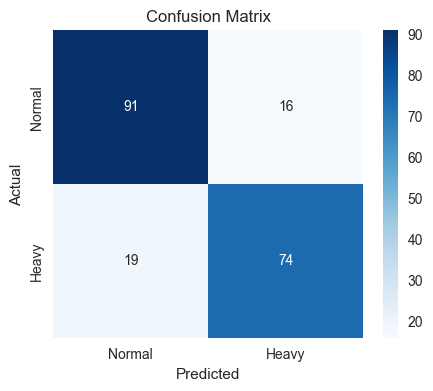

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Heavy"],
            yticklabels=["Normal", "Heavy"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [14]:
import joblib
joblib.dump(lr, "final_heavy_user_model1.pkl")


['final_heavy_user_model1.pkl']